In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
df_car = pd.read_csv("Car or van.csv")
df_age = pd.read_csv("age.csv")
df_distance_travelled = pd.read_csv("Distance_travelled_to _work.csv")
df_economic_act = pd.read_csv("economic activity.csv")

In [3]:
df_car = df_car.drop(["date", "Cars: All categories: Car or van availability; measures: Value", "Cars: sum of All cars or vans in the area; measures: Value"], axis = 1)

In [4]:
df_car.head(5)

,geography,geography code,Rural Urban,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value
0,Darlington,E06000005,Total,13052,20682,10450,1962,524
1,County Durham,E06000047,Total,60926,96086,52740,10775,3276
2,Hartlepool,E06000001,Total,14268,16573,7662,1535,396
3,Middlesbrough,E06000002,Total,21488,22963,10207,1945,600
4,Northumberland,E06000057,Total,30543,60875,36916,7671,2529


In [5]:
df_car["Cars: (2, 3, 4) car or van in household; measures: Value"] = df_car["Cars: 2 cars or vans in household; measures: Value"] + df_car["Cars: 3 cars or vans in household; measures: Value"] + df_car["Cars: 4 or more cars or vans in household; measures: Value"]

In [7]:
df_car = df_car.drop(["Cars: 2 cars or vans in household; measures: Value", "Cars: 3 cars or vans in household; measures: Value", "Cars: 4 or more cars or vans in household; measures: Value"], axis =1)

In [8]:
df_car.head(5)

,geography,geography code,Rural Urban,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,"Cars: (2, 3, 4) car or van in household; measures: Value"
0,Darlington,E06000005,Total,13052,20682,12936
1,County Durham,E06000047,Total,60926,96086,66791
2,Hartlepool,E06000001,Total,14268,16573,9593
3,Middlesbrough,E06000002,Total,21488,22963,12752
4,Northumberland,E06000057,Total,30543,60875,47116


In [9]:
df_age = df_age.drop(["date", "Age: All usual residents; measures: Value","Age: Mean Age; measures: Value", "Age: Median Age; measures: Value" ], axis = 1)

In [10]:
df_age.head(5)

,geography,geography code,Rural Urban,Age: Age 0 to 4; measures: Value,Age: Age 5 to 7; measures: Value,Age: Age 8 to 9; measures: Value,Age: Age 10 to 14; measures: Value,Age: Age 15; measures: Value,Age: Age 16 to 17; measures: Value,Age: Age 18 to 19; measures: Value,Age: Age 20 to 24; measures: Value,Age: Age 25 to 29; measures: Value,Age: Age 30 to 44; measures: Value,Age: Age 45 to 59; measures: Value,Age: Age 60 to 64; measures: Value,Age: Age 65 to 74; measures: Value,Age: Age 75 to 84; measures: Value,Age: Age 85 to 89; measures: Value,Age: Age 90 and over; measures: Value
0,Darlington,E06000005,Total,6579,3790,2284,6224,1330,2721,2357,6071,6607,20917,21560,6685,9717,6172,1740,810
1,County Durham,E06000047,Total,28574,15818,9841,27869,5882,12107,15278,35155,30628,96150,108200,35395,50883,30635,7321,3506
2,Hartlepool,E06000001,Total,5698,3202,1990,5653,1257,2570,2451,5955,5622,16869,19326,5837,8174,5568,1323,533
3,Middlesbrough,E06000002,Total,9431,5178,3098,8485,1811,3747,4506,11690,9765,25414,27065,7531,10833,7393,1658,807
4,Northumberland,E06000057,Total,16003,9863,6482,17677,3841,7631,6992,16224,16187,56156,71135,24533,34366,21018,5233,2687


In [11]:
df_age["Young 0-19"] = df_age["Age: Age 0 to 4; measures: Value"] + df_age["Age: Age 5 to 7; measures: Value"] + df_age["Age: Age 8 to 9; measures: Value"] + df_age["Age: Age 10 to 14; measures: Value"] + df_age["Age: Age 15; measures: Value"] + df_age["Age: Age 16 to 17; measures: Value"] + df_age["Age: Age 18 to 19; measures: Value"]

In [12]:
df_age["Working-age 20-64"] = df_age["Age: Age 20 to 24; measures: Value"] + df_age["Age: Age 25 to 29; measures: Value"] + df_age["Age: Age 30 to 44; measures: Value"] + df_age["Age: Age 45 to 59; measures: Value"] + df_age["Age: Age 60 to 64; measures: Value"]

In [13]:
df_age["Retired-age 65-90"] = df_age["Age: Age 65 to 74; measures: Value"] + df_age["Age: Age 75 to 84; measures: Value"] + df_age["Age: Age 85 to 89; measures: Value"] + df_age["Age: Age 90 and over; measures: Value"]

In [16]:
df_age.columns.tolist()

['geography',
 'geography code',
 'Rural Urban',
 'Age: Age 0 to 4; measures: Value',
 'Age: Age 5 to 7; measures: Value',
 'Age: Age 8 to 9; measures: Value',
 'Age: Age 10 to 14; measures: Value',
 'Age: Age 15; measures: Value',
 'Age: Age 16 to 17; measures: Value',
 'Age: Age 18 to 19; measures: Value',
 'Age: Age 20 to 24; measures: Value',
 'Age: Age 25 to 29; measures: Value',
 'Age: Age 30 to 44; measures: Value',
 'Age: Age 45 to 59; measures: Value',
 'Age: Age 60 to 64; measures: Value',
 'Age: Age 65 to 74; measures: Value',
 'Age: Age 75 to 84; measures: Value',
 'Age: Age 85 to 89; measures: Value',
 'Age: Age 90 and over; measures: Value',
 'Young 0-19',
 'Working-age 20-64',
 'Retired-age 65-90']

In [17]:
df_age = df_age.drop(['Rural Urban',
 'Age: Age 0 to 4; measures: Value',
 'Age: Age 5 to 7; measures: Value',
 'Age: Age 8 to 9; measures: Value',
 'Age: Age 10 to 14; measures: Value',
 'Age: Age 15; measures: Value',
 'Age: Age 16 to 17; measures: Value',
 'Age: Age 18 to 19; measures: Value',
 'Age: Age 20 to 24; measures: Value',
 'Age: Age 25 to 29; measures: Value',
 'Age: Age 30 to 44; measures: Value',
 'Age: Age 45 to 59; measures: Value',
 'Age: Age 60 to 64; measures: Value',
 'Age: Age 65 to 74; measures: Value',
 'Age: Age 75 to 84; measures: Value',
 'Age: Age 85 to 89; measures: Value',
 'Age: Age 90 and over; measures: Value', "geography"], axis =1)

In [19]:
df_age.head(5)

,geography code,Young 0-19,Working-age 20-64,Retired-age 65-90
0,E06000005,25285,61840,18439
1,E06000047,115369,305528,92345
2,E06000001,22821,53609,15598
3,E06000002,36256,81465,20691
4,E06000057,68489,184235,63304


In [20]:
df_distance_travelled = df_distance_travelled.drop(["date", "Distance travelled to work: All categories: Distance travelled to work; measures: Value","Distance travelled to work: Total distance (km); measures: Value", "Distance travelled to work: Average distance (km); measures: Value"], axis = 1)

In [21]:
df_distance_travelled.info()

<class 'pandas.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 13 columns):
 #   Column                                                                    Non-Null Count  Dtype
---  ------                                                                    --------------  -----
 0   geography                                                                 174 non-null    str  
 1   geography code                                                            174 non-null    str  
 2   Rural Urban                                                               174 non-null    str  
 3   Distance travelled to work: Less than 2km; measures: Value                174 non-null    int64
 4   Distance travelled to work: 2km to less than 5km; measures: Value         174 non-null    int64
 5   Distance travelled to work: 5km to less than 10km; measures: Value        174 non-null    int64
 6   Distance travelled to work: 10km to less than 20km; measures: Value       174 non-null    int

In [22]:
df_distance_travelled.head(5)

,geography,geography code,Rural Urban,Distance travelled to work: Less than 2km; measures: Value,Distance travelled to work: 2km to less than 5km; measures: Value,Distance travelled to work: 5km to less than 10km; measures: Value,Distance travelled to work: 10km to less than 20km; measures: Value,Distance travelled to work: 20km to less than 30km; measures: Value,Distance travelled to work: 30km to less than 40km; measures: Value,Distance travelled to work: 40km to less than 60km; measures: Value,Distance travelled to work: 60km and over; measures: Value,Distance travelled to work: Work mainly at or from home; measures: Value,Distance travelled to work: Other; measures: Value
0,Darlington,E06000005,Total,11433,12516,4226,5552,4410,793,1234,1502,4180,3168
1,County Durham,E06000047,Total,36588,31877,38010,51191,19810,6846,2222,5704,20652,14994
2,Hartlepool,E06000001,Total,8452,10557,3406,5707,1684,681,489,1154,2473,3164
3,Middlesbrough,E06000002,Total,10393,15799,11414,4137,1281,642,848,1733,3337,4963
4,Northumberland,E06000057,Total,25944,14491,19568,30255,12969,5666,4162,5593,17894,10359


In [23]:
df_distance_travelled["Distance < 10 km"] = df_distance_travelled["Distance travelled to work: Less than 2km; measures: Value"] + df_distance_travelled["Distance travelled to work: 2km to less than 5km; measures: Value"] + df_distance_travelled["Distance travelled to work: 5km to less than 10km; measures: Value"]

In [24]:
df_distance_travelled["10 km < Distance < 30 km"] = df_distance_travelled["Distance travelled to work: 10km to less than 20km; measures: Value"] + df_distance_travelled["Distance travelled to work: 20km to less than 30km; measures: Value"]

In [25]:
df_distance_travelled["30 km < Distanc < 60 km"] = df_distance_travelled["Distance travelled to work: 30km to less than 40km; measures: Value"] + df_distance_travelled["Distance travelled to work: 40km to less than 60km; measures: Value"] + df_distance_travelled["Distance travelled to work: 60km and over; measures: Value"]

In [26]:
df_distance_travelled.columns.tolist()

['geography',
 'geography code',
 'Rural Urban',
 'Distance travelled to work: Less than 2km; measures: Value',
 'Distance travelled to work: 2km to less than 5km; measures: Value',
 'Distance travelled to work: 5km to less than 10km; measures: Value',
 'Distance travelled to work: 10km to less than 20km; measures: Value',
 'Distance travelled to work: 20km to less than 30km; measures: Value',
 'Distance travelled to work: 30km to less than 40km; measures: Value',
 'Distance travelled to work: 40km to less than 60km; measures: Value',
 'Distance travelled to work: 60km and over; measures: Value',
 'Distance travelled to work: Work mainly at or from home; measures: Value',
 'Distance travelled to work: Other; measures: Value',
 'Distance < 10 km',
 '10 km < Distance < 30 km',
 '30 km < Distanc < 60 km']

In [28]:
df_distance_travelled = df_distance_travelled.drop(['geography',
 'Rural Urban',
 'Distance travelled to work: Less than 2km; measures: Value',
 'Distance travelled to work: 2km to less than 5km; measures: Value',
 'Distance travelled to work: 5km to less than 10km; measures: Value',
 'Distance travelled to work: 10km to less than 20km; measures: Value',
 'Distance travelled to work: 20km to less than 30km; measures: Value',
 'Distance travelled to work: 30km to less than 40km; measures: Value',
 'Distance travelled to work: 40km to less than 60km; measures: Value',
 'Distance travelled to work: 60km and over; measures: Value',
 'Distance travelled to work: Other; measures: Value'], axis = 1)

In [29]:
df_distance_travelled.head(5)

,geography code,Distance travelled to work: Work mainly at or from home; measures: Value,Distance < 10 km,10 km < Distance < 30 km,30 km < Distanc < 60 km
0,E06000005,4180,28175,9962,3529
1,E06000047,20652,106475,71001,14772
2,E06000001,2473,22415,7391,2324
3,E06000002,3337,37606,5418,3223
4,E06000057,17894,60003,43224,15421


In [30]:
df_economic_act = df_economic_act.drop(["date", "Economic Activity: All categories: Economic activity; measures: Value", "Economic Activity: Economically active: Total; measures: Value", "Economic Activity: Economically inactive: Total; measures: Value"], axis = 1)

In [31]:
df_economic_act.head(5)

,geography,geography code,Rural Urban,Economic Activity: Economically active: Employee: Part-time; measures: Value,Economic Activity: Economically active: Employee: Full-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Full-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Full-time; measures: Value,Economic Activity: Economically active: Unemployed; measures: Value,Economic Activity: Economically active: Full-time student; measures: Value,Economic Activity: Economically inactive: Retired; measures: Value,Economic Activity: Economically inactive: Student (including full-time students); measures: Value,Economic Activity: Economically inactive: Looking after home or family; measures: Value,Economic Activity: Economically inactive: Long-term sick or disabled; measures: Value,Economic Activity: Economically inactive: Other; measures: Value
0,Darlington,E06000005,Total,11555,30337,234,1254,1289,2818,4002,1954,12214,2742,3081,3737,1418
1,County Durham,E06000047,Total,50595,143922,1052,5717,5799,12741,17013,10262,65444,23837,14190,24887,8337
2,Hartlepool,E06000001,Total,10092,22635,212,846,892,1855,5194,1787,10621,3042,3265,4733,1630
3,Middlesbrough,E06000002,Total,15063,31301,300,1068,1331,2472,7631,4416,13922,7453,5569,6841,3184
4,Northumberland,E06000057,Total,34368,86380,993,5351,5151,10568,10329,5128,43897,8108,8368,10321,4262


In [32]:
df_economic_act.info()

<class 'pandas.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 16 columns):
 #   Column                                                                                               Non-Null Count  Dtype
---  ------                                                                                               --------------  -----
 0   geography                                                                                            174 non-null    str  
 1   geography code                                                                                       174 non-null    str  
 2   Rural Urban                                                                                          174 non-null    str  
 3   Economic Activity: Economically active: Employee: Part-time; measures: Value                         174 non-null    int64
 4   Economic Activity: Economically active: Employee: Full-time; measures: Value                         174 non-null    int64
 5   Econo

In [35]:
df_economic_act["Economically active"] = df_economic_act["Economic Activity: Economically active: Employee: Part-time; measures: Value"] + df_economic_act["Economic Activity: Economically active: Employee: Full-time; measures: Value"] + df_economic_act["Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value"] + df_economic_act["Economic Activity: Economically active: Self-employed with employees: Full-time; measures: Value"] + df_economic_act["Economic Activity: Economically active: Self-employed without employees: Part-time; measures: Value"] + df_economic_act["Economic Activity: Economically active: Self-employed without employees: Full-time; measures: Value"] + df_economic_act["Economic Activity: Economically active: Full-time student; measures: Value"]

In [34]:
df_economic_act["Unemployed"] = df_economic_act["Economic Activity: Economically active: Unemployed; measures: Value"]

In [37]:
df_economic_act["Economically Inactive"] = df_economic_act["Economic Activity: Economically inactive: Retired; measures: Value"] + df_economic_act["Economic Activity: Economically inactive: Student (including full-time students); measures: Value"] + df_economic_act["Economic Activity: Economically inactive: Looking after home or family; measures: Value"] + df_economic_act["Economic Activity: Economically inactive: Long-term sick or disabled; measures: Value"] + df_economic_act["Economic Activity: Economically inactive: Other; measures: Value"]

In [38]:
df_economic_act.columns.tolist()

['geography',
 'geography code',
 'Rural Urban',
 'Economic Activity: Economically active: Employee: Part-time; measures: Value',
 'Economic Activity: Economically active: Employee: Full-time; measures: Value',
 'Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value',
 'Economic Activity: Economically active: Self-employed with employees: Full-time; measures: Value',
 'Economic Activity: Economically active: Self-employed without employees: Part-time; measures: Value',
 'Economic Activity: Economically active: Self-employed without employees: Full-time; measures: Value',
 'Economic Activity: Economically active: Unemployed; measures: Value',
 'Economic Activity: Economically active: Full-time student; measures: Value',
 'Economic Activity: Economically inactive: Retired; measures: Value',
 'Economic Activity: Economically inactive: Student (including full-time students); measures: Value',
 'Economic Activity: Economically inactive: Looking aft

In [39]:
df_economic_act  = df_economic_act.drop(['geography',
 'Rural Urban',
 'Economic Activity: Economically active: Employee: Part-time; measures: Value',
 'Economic Activity: Economically active: Employee: Full-time; measures: Value',
 'Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value',
 'Economic Activity: Economically active: Self-employed with employees: Full-time; measures: Value',
 'Economic Activity: Economically active: Self-employed without employees: Part-time; measures: Value',
 'Economic Activity: Economically active: Self-employed without employees: Full-time; measures: Value',
 'Economic Activity: Economically active: Unemployed; measures: Value',
 'Economic Activity: Economically active: Full-time student; measures: Value',
 'Economic Activity: Economically inactive: Retired; measures: Value',
 'Economic Activity: Economically inactive: Student (including full-time students); measures: Value',
 'Economic Activity: Economically inactive: Looking after home or family; measures: Value',
 'Economic Activity: Economically inactive: Long-term sick or disabled; measures: Value',
 'Economic Activity: Economically inactive: Other; measures: Value',
 'Economic active'], axis = 1)

In [40]:
df_economic_act.head(5)

,geography code,Unemployed,Economically active,Economically Inactive
0,E06000005,4002,49441,23192
1,E06000047,17013,230088,136695
2,E06000001,5194,38319,23291
3,E06000002,7631,55951,36969
4,E06000057,10329,147939,74956


In [41]:
merged_df = df_car.merge(df_age, on="geography code", how="inner").merge(df_distance_travelled, on="geography code", how="inner").merge(df_economic_act, on="geography code", how="inner")

In [42]:
merged_df.head(5)

,geography,geography code,Rural Urban,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,"Cars: (2, 3, 4) car or van in household; measures: Value",Young 0-19,Working-age 20-64,Retired-age 65-90,Distance travelled to work: Work mainly at or from home; measures: Value,Distance < 10 km,10 km < Distance < 30 km,30 km < Distanc < 60 km,Unemployed,Economically active,Economically Inactive
0,Darlington,E06000005,Total,13052,20682,12936,25285,61840,18439,4180,28175,9962,3529,4002,49441,23192
1,County Durham,E06000047,Total,60926,96086,66791,115369,305528,92345,20652,106475,71001,14772,17013,230088,136695
2,Hartlepool,E06000001,Total,14268,16573,9593,22821,53609,15598,2473,22415,7391,2324,5194,38319,23291
3,Middlesbrough,E06000002,Total,21488,22963,12752,36256,81465,20691,3337,37606,5418,3223,7631,55951,36969
4,Northumberland,E06000057,Total,30543,60875,47116,68489,184235,63304,17894,60003,43224,15421,10329,147939,74956


In [43]:
final_df = merged_df.iloc[:, 3:]

In [44]:
final_df.head(3)

,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,"Cars: (2, 3, 4) car or van in household; measures: Value",Young 0-19,Working-age 20-64,Retired-age 65-90,Distance travelled to work: Work mainly at or from home; measures: Value,Distance < 10 km,10 km < Distance < 30 km,30 km < Distanc < 60 km,Unemployed,Economically active,Economically Inactive
0,13052,20682,12936,25285,61840,18439,4180,28175,9962,3529,4002,49441,23192
1,60926,96086,66791,115369,305528,92345,20652,106475,71001,14772,17013,230088,136695
2,14268,16573,9593,22821,53609,15598,2473,22415,7391,2324,5194,38319,23291


In [45]:
scalar = StandardScaler()
scaled_data = scalar.fit_transform(final_df)

In [46]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

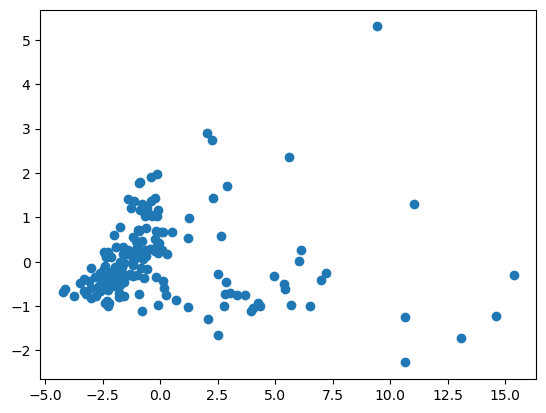

In [47]:
plt.scatter(pca_result[:,0], pca_result[:,1])

In [48]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components = 2, random_state = 1729) 
tsne_result = tsne.fit_transform(scaled_data)

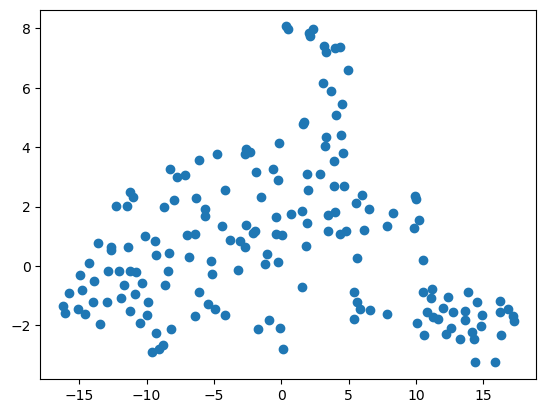

In [49]:
plt.scatter(tsne_result[:,0], tsne_result[:,1])

c:\Users\Aman Kumar Singh\anaconda3\envs\text_analytics\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


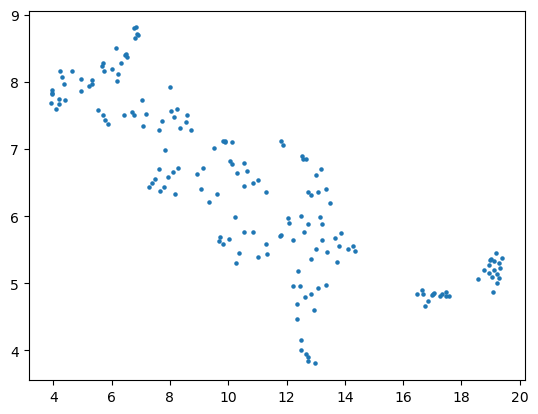

In [82]:
from umap.umap_ import UMAP
umap = UMAP(random_state=100)
embedding = umap.fit_transform(scaled_data)
plt.scatter(embedding[:,0], embedding[:,1], s=5)

In [69]:
from umap.umap_ import UMAP
umap = UMAP(n_neighbors=10, min_dist=0.1, random_state)
embedding = umap.fit_transform(scaled_data)
plt.scatter(embedding[:,0], embedding[:,1], s=5)

SyntaxError: positional argument follows keyword argument (668752416.py, line 2)

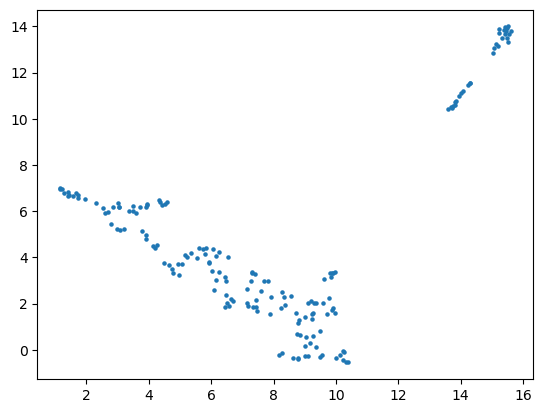

In [65]:
plt.scatter(embedding[:,0], embedding[:,1], s=5)

In [83]:
merged_df.head()

,geography,geography code,Rural Urban,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,"Cars: (2, 3, 4) car or van in household; measures: Value",Young 0-19,Working-age 20-64,Retired-age 65-90,Distance travelled to work: Work mainly at or from home; measures: Value,Distance < 10 km,10 km < Distance < 30 km,30 km < Distanc < 60 km,Unemployed,Economically active,Economically Inactive
0,Darlington,E06000005,Total,13052,20682,12936,25285,61840,18439,4180,28175,9962,3529,4002,49441,23192
1,County Durham,E06000047,Total,60926,96086,66791,115369,305528,92345,20652,106475,71001,14772,17013,230088,136695
2,Hartlepool,E06000001,Total,14268,16573,9593,22821,53609,15598,2473,22415,7391,2324,5194,38319,23291
3,Middlesbrough,E06000002,Total,21488,22963,12752,36256,81465,20691,3337,37606,5418,3223,7631,55951,36969
4,Northumberland,E06000057,Total,30543,60875,47116,68489,184235,63304,17894,60003,43224,15421,10329,147939,74956


In [84]:
merged_df.to_csv("merged_data.csv")